In [85]:
# Importing Pandas to create DataFrame
import pandas as pd
  
df = pd.read_csv("pivot_size_name.csv")

df

,file_size,count
0,149,3
1,155,2
2,156,2
3,158,1
4,159,1
...,...,...
292,4440,1
293,4630,21
294,7818,1
295,18916,1


In [57]:
df.loc[df["file_size"]<2500]["count"].sum()

17390

In [73]:
from math import log10
df["index"] = df.index
df["count_acc"] = df.apply(lambda row: df.loc[df["index"]<=row["index"]]["count"].sum(),axis=1)
df["file_size_log"]=df.apply(lambda row: log10(row["file_size"]),axis=1)
#df["count_acc_log"]=df.apply(lambda row: round(log10(row["count_acc"]),2),axis=1)
df

,file_size,count,index,count_acc,file_size_log,count_acc_log
0,149,3,0,3,2.173186,0.48
1,155,2,1,5,2.190332,0.70
2,156,2,2,7,2.193125,0.85
3,158,1,3,8,2.198657,0.90
4,159,1,4,9,2.201397,0.95
...,...,...,...,...,...,...
292,4440,1,292,17410,3.647383,4.24
293,4630,21,293,17431,3.665581,4.24
294,7818,1,294,17432,3.893096,4.24
295,18916,1,295,17433,4.276829,4.24


Text(0.5, 1.0, 'count undecodable files sizes')

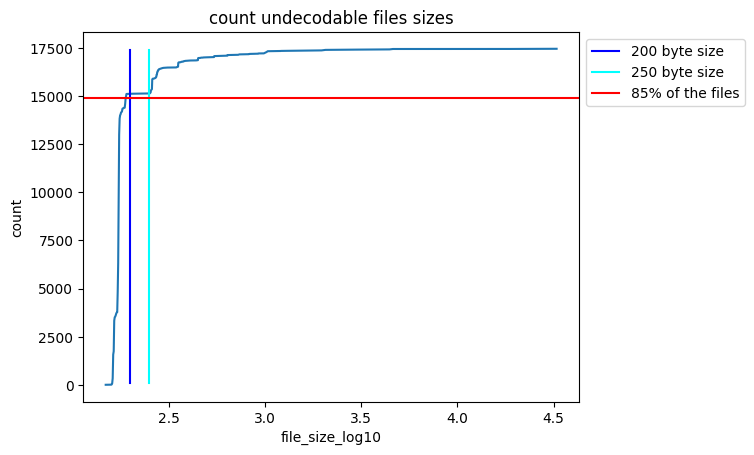

In [84]:

import matplotlib.pyplot as plt

# plotting the points   
plt.plot(df["file_size_log"],df["count_acc"])
plt.axvline(x=log10(200), ymin=0.05, ymax=0.95, color='b', label='200 byte size')
plt.axvline(x=log10(250), ymin=0.05, ymax=0.95, color='cyan', label='250 byte size')
plt.axhline(y=0.85*17500, color='r', linestyle='-',label="85% of the files")

# naming the x axis  
plt.xlabel('file_size_log10')  
# naming the y axis  
plt.ylabel('count')  
plt.legend(bbox_to_anchor=(1.0, 1), loc='upper left')
# giving a title to my g***h  
plt.title('count undecodable files sizes')  